# GW-ODW 2026 Data Challenge - Challenge 2

![GW Open Data Workshop](../../assets/odw.jpeg)

## Challenge 2 (2 points) -- Rookie

Use the data file `challenge2.gwf`, with channel name `H1:CHALLENGE2`. The goal is to identify a BBH signal ($m_1=m_2=30 M_\odot$, spin=0) embedded in colored, Gaussian noise.

## Instructions

1.  **Load the data** from `challenge2.gwf` (URL: `https://dcc.ligo.org/public/0187/G2300818/001/challenge2.gwf`). Channel: `H1:CHALLENGE2`.
2.  **Plot a Q-transform** to visually identify the signal time.
3.  **Generate a template** using `SEOBNRv4_opt` with $m_1=m_2=30 M_\odot$.
4.  **Calculate the PSD** of the data.
5.  **Compute the SNR time series** and find the peak SNR.

## Setup: Install necessary libraries

In [16]:
import sys

!{sys.executable} -m pip install gwpy lalsuite

print("gwpy and lalsuite installed successfully.")

gwpy and lalsuite installed successfully.


## Step 1: Load the data into memory

In [17]:
from gwpy.timeseries import TimeSeries
import requests

data_url = 'https://dcc.ligo.org/public/0187/G2300818/001/challenge2.gwf'
channel_name = 'H1:CHALLENGE2'
local_file = 'challenge2.gwf'

print(f"Downloading {data_url}...")
r = requests.get(data_url)
with open(local_file, 'wb') as f:
    f.write(r.content)

ts = TimeSeries.read(local_file, channel_name)
print(f"Data loaded successfully: {ts.sample_rate} sampling rate, {ts.duration} duration.")

Data loaded successfully: 4096.0 Hz sampling rate, 128.0 s duration.


## Step 2: Visualizing the data with Q-transform

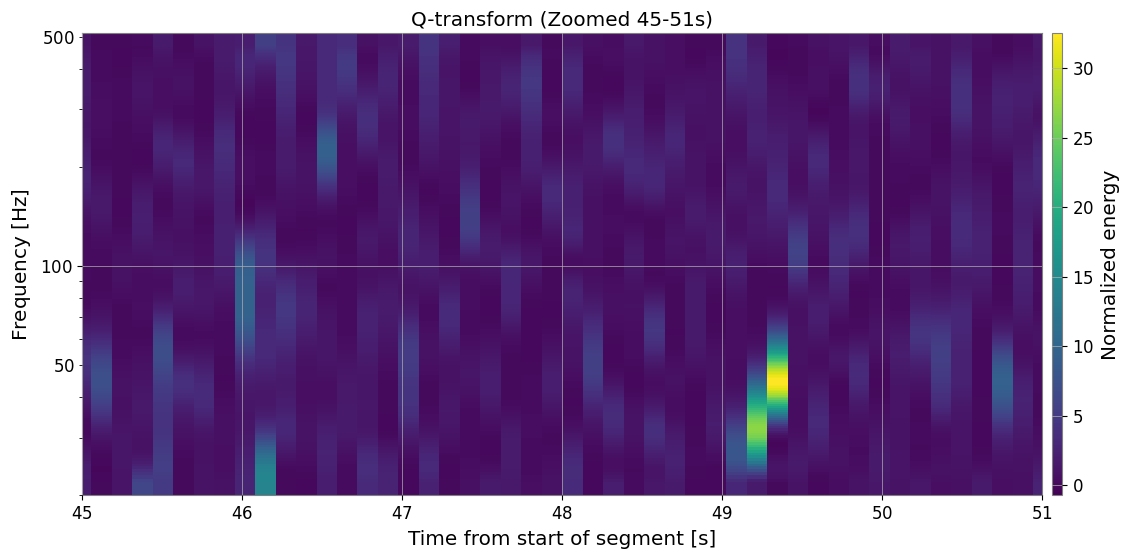

In [42]:
q_transform = ts.q_transform(frange=(20, 512))
plot = q_transform.plot()
ax = plot.gca()

# Zoom in on the time axis: 45 to 51 seconds
ax.set_xlim(45, 51)

ax.set_xscale('linear')
ax.set_yscale('log')

ax.colorbar(label='Normalized energy')
ax.set_xlabel('Time from start of segment [s]')

plt.title('Q-transform (Zoomed 45-51s)')
plot.show()

## Step 3: Generate Template Waveform

We generate a time-domain template using the `SEOBNRv4_opt` approximant for two 30 solar mass black holes.

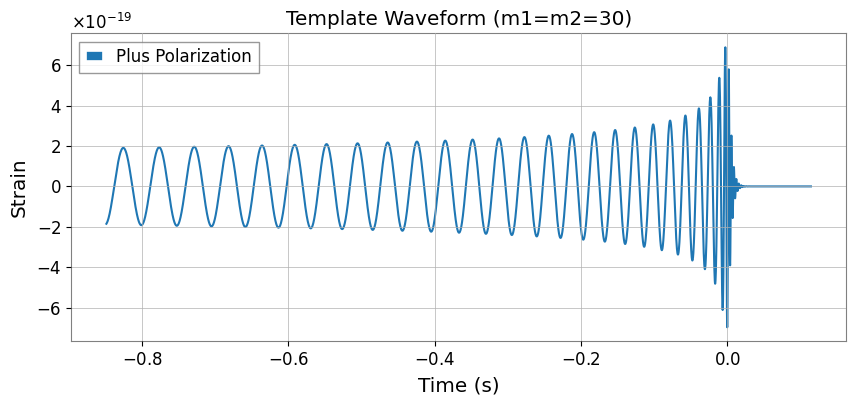

In [19]:
from pycbc.waveform import get_td_waveform

hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                         mass1=30,
                         mass2=30,
                         delta_t=1.0/ts.sample_rate.value,
                         f_lower=20)

plt.figure(figsize=(10, 4))
plt.plot(hp.sample_times, hp, label='Plus Polarization')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.title('Template Waveform (m1=m2=30)')
plt.legend()
plt.show()

## Step 4: Calculate the PSD of the data

We calculate the Power Spectral Density (PSD) to characterize the noise, plotting from 20 Hz to the Nyquist frequency.

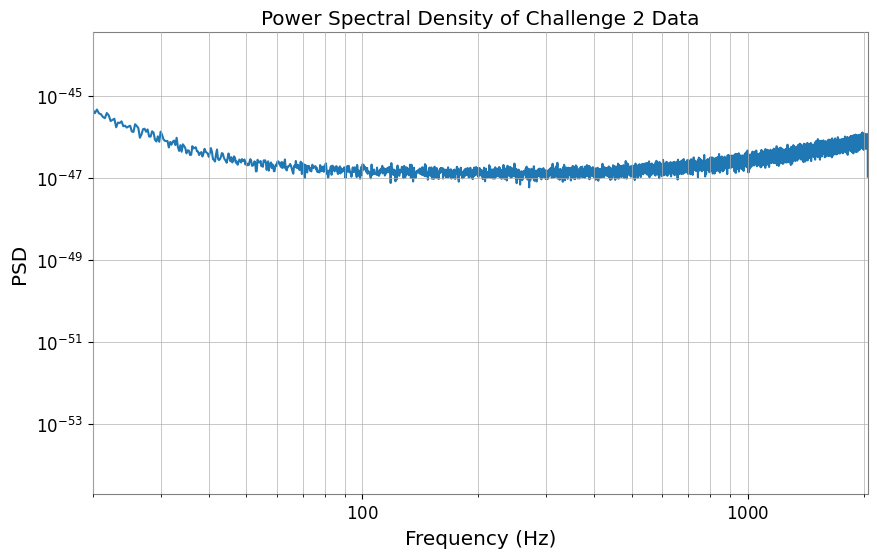

In [20]:
# Step 4: Calculate the PSD of the data
# We ensure delta_f matches the data to avoid errors in matched_filter
delta_f = 1.0 / ts.duration.value
psd = ts.psd(4)

plt.figure(figsize=(10, 6))
plt.loglog(psd.frequencies, psd)
plt.xlim(20, ts.sample_rate.value / 2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('Power Spectral Density of Challenge 2 Data')
plt.grid(True, which='both')
plt.show()

## Step 5: Calculate the SNR Time Series

Using the template and the PSD, we perform matched filtering to find the signal SNR.

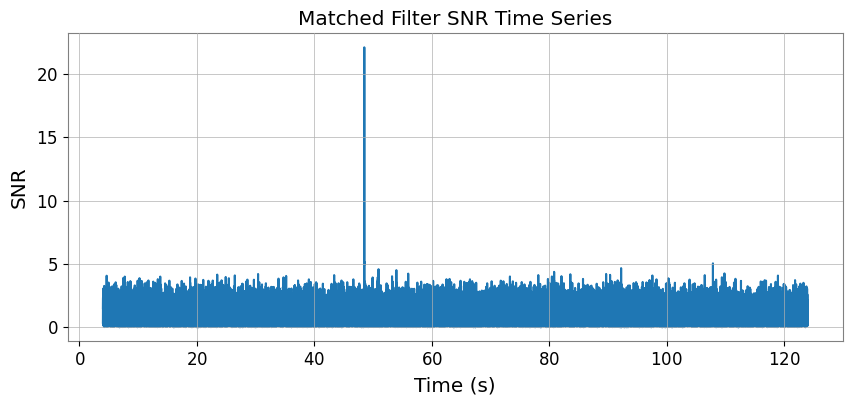

Peak SNR: 22.10 at 48.52 seconds


In [26]:
from pycbc.filter import matched_filter
from pycbc.types import TimeSeries as PyCBCTimeSeries

# Convert GWPy TimeSeries to PyCBC
pycbc_ts = ts.to_pycbc()
# Interpolate PSD to match the data's delta_f
pycbc_psd = psd.to_pycbc()
from pycbc.psd import interpolate
pycbc_psd = interpolate(pycbc_psd, pycbc_ts.delta_f)

# Resize the template to match the data length for matched_filter
hp.resize(len(pycbc_ts))

# Perform matched filtering
snr = matched_filter(hp, pycbc_ts, psd=pycbc_psd, low_frequency_cutoff=20)

# Crop the edges to remove filter transients
snr = snr.crop(4, 4)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(snr.sample_times, abs(snr))
plt.ylabel('SNR')
plt.xlabel('Time (s)')
plt.title('Matched Filter SNR Time Series')
plt.grid(True)
plt.show()

# Find the peak
snr_array = abs(snr).numpy()
peak_snr = snr_array.max()
peak_index = snr_array.argmax()
peak_time = snr.sample_times[peak_index]

print(f'Peak SNR: {peak_snr:.2f} at {peak_time:.2f} seconds')

### Questions for Challenge 2:

**A. From the Q-transform, what is the approximative time of the merger?**

From the Q-transform, the merger seems to occur at approx. 49 seconds.

In [37]:
# The peak values were calculated in the previous cell
print(f"From the SNR time plot, the peak is at {peak_time:.2f} seconds.")

From the SNR time plot, the peak is at 48.52 seconds.


**B. What is the matched filter SNR of the signal?**

In [38]:
print(f"The matched filter SNR of the signal is {peak_snr:.2f}.")

The matched filter SNR of the signal is 22.10.
